## 0. Purpose

This script converts the training data to dataframes. All the classes are undersampled to the number of pixels of the smallest class. The smallest class is the "deadwood". Afterwards a random forest classifier is trained. Feature importance and Accuracy is displayed at the end of the script.

## 1. Import Packages


In [78]:
#%pip install xarray rioxarray pandas matplotlib rasterio
import geopandas as gpd
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import rioxarray
from rasterio import rio
from rasterio import features
from rasterio.enums import Resampling
import numpy as np
from rasterio.transform import Affine
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

## 2. Convert Trainingdata to dataframe

This code block builds the training dataframe.

IF RUNMODE = BANDS; only the original bands of the sent-2 data get used,
IF RUNMODE = INDEX; the orgininal bands and the indices including textures get used

In [79]:
RUNMODE = "INDEX"

if RUNMODE == "INDEX":
    raster = rioxarray.open_rasterio(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_withindices\n22_firsttry.tif")
    raster = raster.assign_coords(band =  ["blue", "green", "red", "rededge1", "rededge2", "rededge3", "nir", "nir_narrow", "swir1", "swir2", "ndvi", "savi", "ndwi", "bsi", "nssi", "contrast", "dissimilarity", "homogeneity", "energy", "correlation", "ASM", "std", "trainclass"])
    raster = raster.drop_sel(band="std")

    df = raster.stack(samples=("y", "x")).to_pandas().T.dropna()
    df.columns = ["blue", "green", "red", "rededge1", "rededge2", "rededge3", "nir", "nir_narrow", "swir1", "swir2", "ndvi", "savi", "ndwi", "bsi", "nssi", "contrast", "dissimilarity", "homogeneity", "energy", "correlation", "ASM", "trainclass"] # wieder benennen für übersicht
    df["trainclass"] = (df["trainclass"] * 10000).round().astype(int) # das muss ich machen, weil ich alles durch 10.000 geteilt habe um auf reflactance werte zu kommen. Bei der Klasse macht das natürlich keinen Sinn.


if RUNMODE == "BANDS":

    raster = rioxarray.open_rasterio(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_clean_full\n22.tif")
    raster = raster.assign_coords(band =  ["blue", "green", "red", "rededge1", "rededge2", "rededge3", "nir", "nir_narrow", "swir1", "swir2", "trainclass"])

    df = raster.stack(samples=("y", "x")).to_pandas().T.dropna()
    df.columns = ["blue", "green", "red", "rededge1", "rededge2", "rededge3", "nir", "nir_narrow", "swir1", "swir2","trainclass"] # wieder benennen für übersicht
    df["trainclass"] = (df["trainclass"] * 10000).round().astype(int)

### 2.2 Creating balanced training data

Die Kategorie 2 ("deadwood") ist etwas das nadelöhr.

In [80]:
min_size = df["trainclass"].value_counts().min()
print(f"Smallest class size is: {min_size}")

balanced_list = []
for class_id in df["trainclass"].unique():
    class_subset = df[df["trainclass"] == class_id]
    sampled_subset = class_subset.sample(n=min_size, random_state=42)
    balanced_list.append(sampled_subset)
df = pd.concat(balanced_list).reset_index(drop=True)
print("Columns in df_balanced:", df.columns.tolist())
print("Value counts:\n", df["trainclass"].value_counts())

Smallest class size is: 1513
Columns in df_balanced: ['blue', 'green', 'red', 'rededge1', 'rededge2', 'rededge3', 'nir', 'nir_narrow', 'swir1', 'swir2', 'ndvi', 'savi', 'ndwi', 'bsi', 'nssi', 'contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM', 'trainclass']
Value counts:
 trainclass
3    1513
1    1513
2    1513
Name: count, dtype: int64


## 3. Random Forest


### 3.1 Creating training and validation data

In [81]:
preds = df.drop(columns=["trainclass"])
forestclass = df["trainclass"]
pred_train, pred_test, forestclass_train, forestclass_test = train_test_split(preds, forestclass, test_size=0.3, random_state=42)


### 3.2 Training

In [82]:
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(pred_train, forestclass_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### 3.3 Predicting


In [83]:
predictions = rf.predict(pred_test)

### 3.4 Accuracy Assessment


1 = clear,
2 = deadwood,
3 = undisturbed

#### 3.4.1 User and Producer Accuracy

precision = user accuracy

recall = producer accuracy

In [84]:
print(classification_report(forestclass_test, predictions))


              precision    recall  f1-score   support

           1       0.88      0.93      0.90       444
           2       0.92      0.91      0.91       441
           3       0.97      0.92      0.94       477

    accuracy                           0.92      1362
   macro avg       0.92      0.92      0.92      1362
weighted avg       0.92      0.92      0.92      1362



#### 3.4.2 Confusion matrix

In [85]:

confusion_matrix = pd.crosstab(forestclass_test, predictions,
                 rownames=['Actual'],
                 colnames=['Predicted'],
                 margins=True)

print(confusion_matrix)

Predicted    1    2    3   All
Actual                        
1          412   27    5   444
2           31  400   10   441
3           27   10  440   477
All        470  437  455  1362


### 3.4.3 Feature Importance

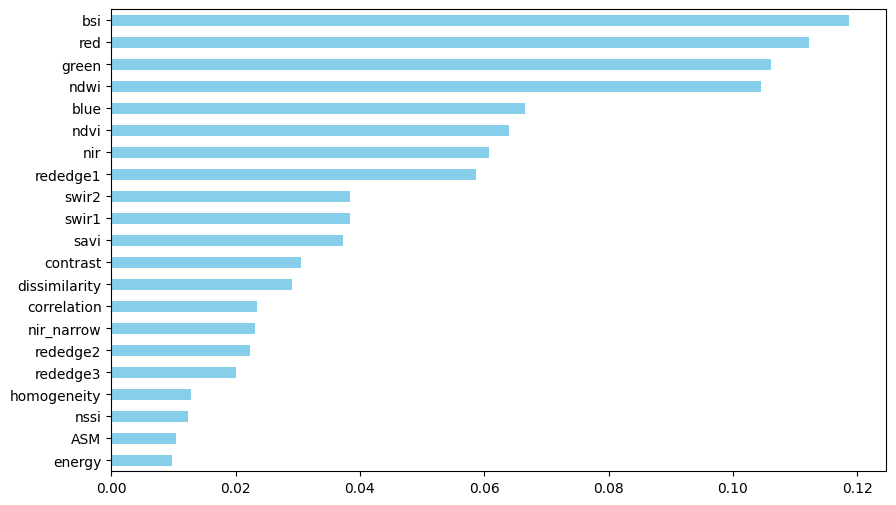

In [86]:
importances = pd.Series(rf.feature_importances_, index=preds.columns)
importances = importances.sort_values(ascending=True)
importances.plot(kind='barh', color='skyblue', figsize=(10, 6))
plt.show()